In [1]:
import os
import torch
import numpy as np
import pandas as pd
import math

import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (mean_squared_error, mean_absolute_error,r2_score, mean_absolute_percentage_error,)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [2]:
yemen_data = torch.load("data_sets/yemen_rainfall_sequences.pt")
china_data = torch.load("data_sets/china_rainfall_sequences.pt")
south_af_data = torch.load("data_sets/south_af_rainfall_sequences.pt")
nigeria_data = torch.load("data_sets/nigeria_rainfall_sequences.pt")

In [3]:
class iTransformer(nn.Module):
    def __init__(self, num_features, seq_len, num_pcodes, d_model=128, n_heads=4, num_layers=3, d_ff=256, dropout=0.1, pcode_embed_dim=16):
        super().__init__()

        # 1. PCODE embedding
        self.pcode_emb = nn.Embedding(num_pcodes, pcode_embed_dim)
        # 2. Inverted embedding (Time - Representation)
        self.value_embedding = nn.Linear(seq_len, d_model)
        # 3. Feature (token) embedding
        self.feature_embedding = nn.Parameter(torch.randn(1, num_features, d_model))
        # 4. Combine dim
        self.total_dim = d_model + pcode_embed_dim

        # 5. Transformer Encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=self.total_dim,
            nhead=n_heads,
            dim_feedforward=d_ff,
            dropout=dropout,
            batch_first=True,
            activation='gelu'
        )

        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers)

        # 6. LayerNorm
        self.norm = nn.LayerNorm(self.total_dim)

        # 7. Prediction head
        self.head = nn.Sequential(
            nn.Linear(self.total_dim, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, x, pcode):
        # x: (B, T, F)

        B, T, F = x.shape

        # 1. Invert → (B, F, T)
        x = x.permute(0, 2, 1)

        # 2. Project time → representation
        x = self.value_embedding(x)  # (B, F, d_model)

        # 3. Add feature embedding (VERY IMPORTANT - paper detail)
        x = x + self.feature_embedding

        # 4. PCODE embedding
        p_emb = self.pcode_emb(pcode)  # (B, E)
        p_emb = p_emb.unsqueeze(1).expand(-1, F, -1)

        # 5. Concatenate
        x = torch.cat([x, p_emb], dim=-1)

        # 6. Normalize
        x = self.norm(x)

        # 7. Transformer (attention across FEATURES)
        x = self.encoder(x)

        # 8. Aggregation (mean over features)
        x = x.mean(dim=1)

        # 9. Prediction
        out = self.head(x)

        return out.squeeze()

In [4]:
# Positional Encoding
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer("pe", pe)

    def forward(self, x):

        return x + self.pe[:, :x.size(1)]


class Transformer(nn.Module):
    def __init__(self, input_dim, num_pcodes, embed_dim, d_model, n_heads, num_layers, dropout):
        super().__init__()
        
        self.embedding = nn.Embedding(num_pcodes, embed_dim)
        
        self.input_proj = nn.Linear(input_dim + embed_dim, d_model)

        self.pos_encoder = PositionalEncoding(d_model)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_model * 4,
            dropout=dropout,
            activation='gelu',
            batch_first=True
        )
        
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers)
        self.norm = nn.LayerNorm(d_model)  # Layer Normalization

        # Regression Head
        self.fc = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, 1)
        )

    def forward(self, x, pcode):     # Forward Pass 
        emb = self.embedding(pcode)   # PCODE Embedding , shape =  (batch, embed_dim)
        
        emb = emb.unsqueeze(1).repeat(1, x.size(1), 1)  # shape = (batch, seq_len, embed_dim)
        
        x = torch.cat([x, emb], dim=2)
        x = self.input_proj(x)
        x = self.pos_encoder(x)
        x = self.transformer(x)
        x = self.norm(x)
        x = x[:, -1, :]
        x = self.fc(x)            # Regression Output

        return x.squeeze(-1)

In [5]:
china_model = iTransformer(
    num_features=14,
    seq_len=24,
    num_pcodes=318,
    d_model=128,
    n_heads=4,
    num_layers=4,
    d_ff=256,
    dropout=0.10724793976589116,
    pcode_embed_dim=16
).to(device)

nigeria_model = iTransformer(
    num_features=14,
    seq_len=24,
    num_pcodes=751,
    d_model=128,
    n_heads=8,
    num_layers=4,
    d_ff=128,
    dropout=0.16867655723135877,
    pcode_embed_dim=8
).to(device)

yemen_model = iTransformer(
    num_features=14,
    seq_len=24,
    num_pcodes=318,
    d_model=64,
    n_heads=4,
    num_layers=2,
    d_ff=512,
    dropout=0.10496930760427328,
    pcode_embed_dim=32
).to(device)

south_africa_model = Transformer(
    input_dim= 14,    #X_train.shape[2],
    num_pcodes=52,
    embed_dim=4,
    d_model=128,
    n_heads=2,
    num_layers=3,
    dropout=0.22027227653243042
).to(device)



In [ ]:
china_model.load_state_dict(torch.load("models/china_itf_model.pth"))
china_model.eval()

nigeria_model.load_state_dict(torch.load("models/nigeria_itf_model.pth"))
nigeria_model.eval()

yemen_model.load_state_dict(torch.load("models/iTransformer_yeman_yr_model.pth"))
yemen_model.eval()

south_africa_model.load_state_dict(torch.load("models/south_africa_tf_model.pth"))
south_africa_model.eval()

Transformer(
  (embedding): Embedding(52, 4)
  (input_proj): Linear(in_features=18, out_features=128, bias=True)
  (pos_encoder): PositionalEncoding()
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=512, bias=True)
        (dropout): Dropout(p=0.22027227653243042, inplace=False)
        (linear2): Linear(in_features=512, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.22027227653243042, inplace=False)
        (dropout2): Dropout(p=0.22027227653243042, inplace=False)
      )
    )
  )
  (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (fc): Sequential(
    (0):

In [7]:
yemen_data.keys()

dict_keys(['X_train_yemen', 'y_train_yemen', 'p_train_yemen', 'X_val_yemen', 'y_val_yemen', 'p_val_yemen', 'X_test_yemen', 'y_test_yemen', 'p_test_yemen'])

In [8]:
X_test_yemen = yemen_data["X_test_yemen"]
X_test_china = china_data["X_test_china"]
X_test_sa = south_af_data["X_test_south_af"]
X_test_nigeria = nigeria_data["X_test_nigeria"]

y_test_yemen = yemen_data["y_test_yemen"]
y_test_china = china_data["y_test_china"]
y_test_sa = south_af_data["y_test_south_af"]
y_test_nigeria = nigeria_data["y_test_nigeria"]

p_test_yemen = yemen_data["p_test_yemen"]
p_test_china = china_data["p_test_china"]
p_test_sa = south_af_data["p_test_south_af"]
p_test_nigeria = nigeria_data["p_test_nigeria"]

In [9]:
X_test_yemen = torch.tensor(X_test_yemen, dtype=torch.float32).to(device)
X_test_china = torch.tensor(X_test_china,dtype=torch.float32).to(device)
X_test_sa = torch.tensor(X_test_sa,dtype=torch.float32).to(device)
X_test_nigeria = torch.tensor(X_test_nigeria,dtype=torch.float32).to(device)

p_test_yemen = torch.tensor(p_test_yemen,dtype=torch.long).to(device)
p_test_china = torch.tensor(p_test_china,dtype=torch.long).to(device)
p_test_sa = torch.tensor(p_test_sa,dtype=torch.long).to(device)
p_test_nigeria = torch.tensor(p_test_nigeria,dtype=torch.long).to(device)


/tmp/ipykernel_171075/2501527259.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_test_yemen = torch.tensor(X_test_yemen, dtype=torch.float32).to(device)
/tmp/ipykernel_171075/2501527259.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_test_china = torch.tensor(X_test_china,dtype=torch.float32).to(device)
/tmp/ipykernel_171075/2501527259.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_test_sa = torch.tensor(X_test_sa,dtype=torch.float32).to(device)
/tmp/ipykernel_171075/2501527259.py:4: UserWarning: To copy construct from 

In [10]:
print("China X:", X_test_china.shape)
print("China P:", p_test_china.shape)

print("Nigeria X:", X_test_nigeria.shape)
print("Nigeria P:", p_test_nigeria.shape)

print("South Africa X:", X_test_sa.shape)
print("South Africa P:", p_test_sa.shape)

print("Yemen X:", X_test_yemen.shape)
print("Yemen P:", p_test_yemen.shape)


China X: torch.Size([12168, 24, 14])
China P: torch.Size([12168])
Nigeria X: torch.Size([117156, 24, 14])
Nigeria P: torch.Size([117156])
South Africa X: torch.Size([7488, 36, 14])
South Africa P: torch.Size([7488])
Yemen X: torch.Size([57240, 24, 14])
Yemen P: torch.Size([57240])


In [11]:

print(X_test_yemen.shape)

torch.Size([57240, 24, 14])


In [12]:
with torch.no_grad():

    china_pred = china_model(X_test_china,p_test_china)
    nigeria_pred = nigeria_model(X_test_nigeria,p_test_nigeria)
    sa_pred = south_africa_model(X_test_sa,p_test_sa)
    yemen_pred = yemen_model(X_test_yemen,p_test_yemen)

In [13]:
china_pred = (china_pred.cpu().numpy().flatten())
nigeria_pred = (nigeria_pred.cpu().numpy().flatten())
sa_pred = (sa_pred.cpu().numpy().flatten())
yemen_pred = (yemen_pred.cpu().numpy().flatten())

In [14]:
print(china_pred.shape)
print(nigeria_pred.shape)
print(sa_pred.shape)
print(yemen_pred.shape)

(12168,)
(117156,)
(7488,)
(57240,)


In [15]:
min_len = min(
    len(china_pred),
    len(nigeria_pred),
    len(sa_pred),
    len(yemen_pred)
)

print("Min length:", min_len)

Min length: 7488


In [16]:
china_pred = china_pred[-min_len:]
nigeria_pred = nigeria_pred[-min_len:]
sa_pred = sa_pred[-min_len:]
yemen_pred = yemen_pred[-min_len:]

In [17]:
y_test_china = y_test_china[-min_len:]
y_test_nigeria = y_test_nigeria[-min_len:]
y_test_sa = y_test_sa[-min_len:]
y_test_yemen = y_test_yemen[-min_len:]

In [18]:
coordination_df = pd.DataFrame({
    "china_pred": china_pred,
    "nigeria_pred": nigeria_pred,
    "sa_pred": sa_pred,
    "yemen_pred": yemen_pred,

    "china_r2": 0.6298,
    "nigeria_r2": 0.8753,
    "sa_r2": 0.6958,
    "yemen_r2": 0.8050,

    "china_rmse": 0.4005,
    "nigeria_rmse": 0.1894,
    "sa_rmse": 0.3375,
    "yemen_rmse": 0.3126
})

In [19]:
coordination_df.to_csv("global_coordination_data.csv",index = False)
coordination_df

,china_pred,nigeria_pred,sa_pred,yemen_pred,china_r2,nigeria_r2,sa_r2,yemen_r2,china_rmse,nigeria_rmse,sa_rmse,yemen_rmse
0,0.469491,0.260686,-0.429434,0.254904,0.6298,0.8753,0.6958,0.805,0.4005,0.1894,0.3375,0.3126
1,0.041159,0.121904,-0.337882,0.227178,0.6298,0.8753,0.6958,0.805,0.4005,0.1894,0.3375,0.3126
2,0.102130,0.016585,-0.421917,0.332703,0.6298,0.8753,0.6958,0.805,0.4005,0.1894,0.3375,0.3126
3,-0.122526,-0.444889,-0.480129,0.266516,0.6298,0.8753,0.6958,0.805,0.4005,0.1894,0.3375,0.3126
4,-0.150898,-0.784681,-0.501493,0.235242,0.6298,0.8753,0.6958,0.805,0.4005,0.1894,0.3375,0.3126
...,...,...,...,...,...,...,...,...,...,...,...,...
7483,-1.108791,-0.936709,0.426197,0.219333,0.6298,0.8753,0.6958,0.805,0.4005,0.1894,0.3375,0.3126
7484,-1.235206,-0.937420,0.512350,0.328583,0.6298,0.8753,0.6958,0.805,0.4005,0.1894,0.3375,0.3126
7485,-1.402639,-0.893664,0.520674,0.298336,0.6298,0.8753,0.6958,0.805,0.4005,0.1894,0.3375,0.3126
7486,-1.462409,-0.943714,0.576891,0.292389,0.6298,0.8753,0.6958,0.805,0.4005,0.1894,0.3375,0.3126


In [20]:
rmse_dict = {
    "china": 0.4005,
    "nigeria": 0.1894,
    "sa": 0.3375,
    "yemen": 0.3126
}

# inverse RMSE
inv_rmse = {k: 1/v for k, v in rmse_dict.items()}

total = sum(inv_rmse.values())

# normalized confidence
conf = {k: v/total for k, v in inv_rmse.items()}

print(conf)

{'china': 0.17913349126315523, 'nigeria': 0.37879072466152935, 'sa': 0.21257174296561085, 'yemen': 0.22950404110970463}


In [21]:
coordination_df = pd.DataFrame({
    "china_pred": china_pred,
    "nigeria_pred": nigeria_pred,
    "sa_pred": sa_pred,
    "yemen_pred": yemen_pred,

    "china_r2": 0.6298,
    "nigeria_r2": 0.8753,
    "sa_r2": 0.6958,
    "yemen_r2": 0.7703,

    "china_conf": conf["china"],
    "nigeria_conf": conf["nigeria"],
    "sa_conf": conf["sa"],
    "yemen_conf": conf["yemen"]
})
coordination_df

,china_pred,nigeria_pred,sa_pred,yemen_pred,china_r2,nigeria_r2,sa_r2,yemen_r2,china_conf,nigeria_conf,sa_conf,yemen_conf
0,0.469491,0.260686,-0.429434,0.254904,0.6298,0.8753,0.6958,0.7703,0.179133,0.378791,0.212572,0.229504
1,0.041159,0.121904,-0.337882,0.227178,0.6298,0.8753,0.6958,0.7703,0.179133,0.378791,0.212572,0.229504
2,0.102130,0.016585,-0.421917,0.332703,0.6298,0.8753,0.6958,0.7703,0.179133,0.378791,0.212572,0.229504
3,-0.122526,-0.444889,-0.480129,0.266516,0.6298,0.8753,0.6958,0.7703,0.179133,0.378791,0.212572,0.229504
4,-0.150898,-0.784681,-0.501493,0.235242,0.6298,0.8753,0.6958,0.7703,0.179133,0.378791,0.212572,0.229504
...,...,...,...,...,...,...,...,...,...,...,...,...
7483,-1.108791,-0.936709,0.426197,0.219333,0.6298,0.8753,0.6958,0.7703,0.179133,0.378791,0.212572,0.229504
7484,-1.235206,-0.937420,0.512350,0.328583,0.6298,0.8753,0.6958,0.7703,0.179133,0.378791,0.212572,0.229504
7485,-1.402639,-0.893664,0.520674,0.298336,0.6298,0.8753,0.6958,0.7703,0.179133,0.378791,0.212572,0.229504
7486,-1.462409,-0.943714,0.576891,0.292389,0.6298,0.8753,0.6958,0.7703,0.179133,0.378791,0.212572,0.229504


In [22]:
global_target = (
    y_test_china.cpu().numpy() +
    y_test_nigeria.cpu().numpy() +
    y_test_sa.cpu().numpy() +
    y_test_yemen.cpu().numpy()
) / 4

print(global_target.shape)

(7488,)


In [23]:
scaler = StandardScaler()
X_coord = scaler.fit_transform(coordination_df)
y_coord = global_target

print(X_coord.shape)
print(y_coord.shape)

(7488, 12)
(7488,)


In [24]:
X_train_coord, X_test_coord, y_train_coord, y_test_coord = train_test_split(
    X_coord,
    y_coord,
    test_size=0.2,
    random_state=42
)

print(X_train_coord.shape)
print(X_test_coord.shape)

(5990, 12)
(1498, 12)


In [25]:
X_train_coord = torch.tensor(X_train_coord, dtype=torch.float32).to(device)
X_test_coord = torch.tensor(X_test_coord, dtype=torch.float32).to(device)

y_train_coord = torch.tensor(y_train_coord, dtype=torch.float32).to(device)
y_test_coord = torch.tensor(y_test_coord, dtype=torch.float32).to(device)

In [26]:
class AttentionCoordinator(nn.Module):
    def __init__(
        self,
        input_dim=12,       # Number of input features
        hidden_dim=64,      # Main hidden size (tunable)
        attn_dim=64,        # Attention layer size (tunable)
        output_dim=1,       # Final output (global rainfall)
        dropout=0.2         # Dropout rate (tunable)
    ):
        super().__init__()

        # Step 1: Feature Projection Layer
        # Converts 12 input features into higher-dimensional space
        # Example: [predictions + R² + confidence] -> 64 features
        self.feature_proj = nn.Linear(input_dim, hidden_dim)

        # Activation function
        self.relu = nn.ReLU()

        # Dropout for regularization
        self.dropout = nn.Dropout(dropout)

        # Step 2: Attention Layer
        # Learns importance of each hidden feature
        self.attention = nn.Sequential(

            # First attention transformation
            nn.Linear(hidden_dim, attn_dim),

            # Non-linearity
            nn.Tanh(),

            # Second transformation to generate attention scores
            nn.Linear(attn_dim, hidden_dim),

            # Convert scores into probabilities
            nn.Softmax(dim=1)
        )

        # Step 3: Regression Head
        # Produces final global rainfall prediction
        self.regressor = nn.Sequential(

            nn.Linear(hidden_dim, hidden_dim // 2),

            nn.ReLU(),

            nn.Dropout(dropout),

            nn.Linear(hidden_dim // 2, output_dim)
        )

    def forward(self, x):

        # Feature projection
        h = self.feature_proj(x)

        # Activation
        h = self.relu(h)

        # Regularization
        h = self.dropout(h)

        # Attention weights
        attn_weights = self.attention(h)

        # Weighted fusion
        h_weighted = h * attn_weights

        # Final prediction
        output = self.regressor(h_weighted)

        return output.squeeze(), attn_weights

In [27]:
hidden_dims = [32, 64, 128]
dropouts = [0.1, 0.2, 0.3]
learning_rates = [0.001, 0.0005]

best_rmse = float("inf")
best_params = None

for hidden_dim in hidden_dims:
    for dropout in dropouts:
        for lr in learning_rates:

            model = AttentionCoordinator(
                input_dim=12,
                hidden_dim=hidden_dim,
                attn_dim=hidden_dim,
                dropout=dropout
            ).to(device)

            optimizer = torch.optim.Adam(
                model.parameters(),
                lr=lr
            )

            criterion = nn.MSELoss()

            # Training
            for epoch in range(50):

                model.train()

                optimizer.zero_grad()

                pred, _ = model(X_train_coord)

                loss = criterion(pred, y_train_coord)

                loss.backward()

                optimizer.step()

                if epoch % 10 == 0:
                    print(f"Epoch {epoch} | Loss: {loss.item():.6f}")

            # Validation
            model.eval()

            with torch.no_grad():
                pred_test,  attention_weights = model(X_test_coord)

                rmse = torch.sqrt(criterion(pred_test, y_test_coord)).item()

            print(
                f"hidden={hidden_dim}, "
                f"dropout={dropout}, "
                f"lr={lr}, "
                f"RMSE={rmse:.4f}"
            )

            if rmse < best_rmse:
                best_rmse = rmse
                best_params = (hidden_dim, dropout, lr)

print("\nBest Params:", best_params)
print("Best RMSE:", best_rmse)

Epoch 0 | Loss: 0.134146
Epoch 10 | Loss: 0.122562
Epoch 20 | Loss: 0.111996
Epoch 30 | Loss: 0.102700
Epoch 40 | Loss: 0.093387
hidden=32, dropout=0.1, lr=0.001, RMSE=0.2845
Epoch 0 | Loss: 0.105278
Epoch 10 | Loss: 0.102171
Epoch 20 | Loss: 0.099344
Epoch 30 | Loss: 0.096658
Epoch 40 | Loss: 0.094337
hidden=32, dropout=0.1, lr=0.0005, RMSE=0.3036
Epoch 0 | Loss: 0.164297
Epoch 10 | Loss: 0.150073
Epoch 20 | Loss: 0.138771
Epoch 30 | Loss: 0.128740
Epoch 40 | Loss: 0.119046
hidden=32, dropout=0.2, lr=0.001, RMSE=0.3270
Epoch 0 | Loss: 0.096312
Epoch 10 | Loss: 0.093816
Epoch 20 | Loss: 0.091953
Epoch 30 | Loss: 0.090678
Epoch 40 | Loss: 0.089866
hidden=32, dropout=0.2, lr=0.0005, RMSE=0.2966
Epoch 0 | Loss: 0.151163
Epoch 10 | Loss: 0.135870
Epoch 20 | Loss: 0.123273
Epoch 30 | Loss: 0.112507
Epoch 40 | Loss: 0.103161
hidden=32, dropout=0.3, lr=0.001, RMSE=0.3031
Epoch 0 | Loss: 0.092592
Epoch 10 | Loss: 0.091824
Epoch 20 | Loss: 0.091573
Epoch 30 | Loss: 0.090935
Epoch 40 | Loss: 0.0

In [29]:
best_hidden_dim = best_params[0]
best_dropout = best_params[1]
best_lr = best_params[2]

final_model = AttentionCoordinator(
    input_dim=12,
    hidden_dim=best_hidden_dim,
    attn_dim=best_hidden_dim,
    dropout=best_dropout
).to(device)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(final_model.parameters(),lr=best_lr)



for epoch in range(100):

    final_model.train()

    optimizer.zero_grad()

    pred, _ = final_model(X_train_coord)

    loss = criterion(pred, y_train_coord)

    loss.backward()

    optimizer.step()

    if epoch % 10 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.6f}")

Epoch 0 | Loss: 0.101989
Epoch 10 | Loss: 0.092249
Epoch 20 | Loss: 0.083300
Epoch 30 | Loss: 0.068098
Epoch 40 | Loss: 0.048180
Epoch 50 | Loss: 0.031613
Epoch 60 | Loss: 0.024554
Epoch 70 | Loss: 0.022876
Epoch 80 | Loss: 0.021463
Epoch 90 | Loss: 0.020830


In [30]:
final_model.eval()

with torch.no_grad():

    final_pred, attention_weights = final_model(X_test_coord)

final_pred = final_pred.cpu().numpy()
y_true = y_test_coord.cpu().numpy()

rmse = np.sqrt(mean_squared_error(y_true, final_pred))
mae = mean_absolute_error(y_true, final_pred)
r2 = r2_score(y_true, final_pred)

print("RMSE :", rmse)
print("MAE  :", mae)
print("R²   :", r2)

RMSE : 0.13714911
MAE  : 0.109922014
R²   : 0.7930059738971201


In [31]:
torch.save(
    final_model.state_dict(),
    "models/coordination_agent.pth"
)

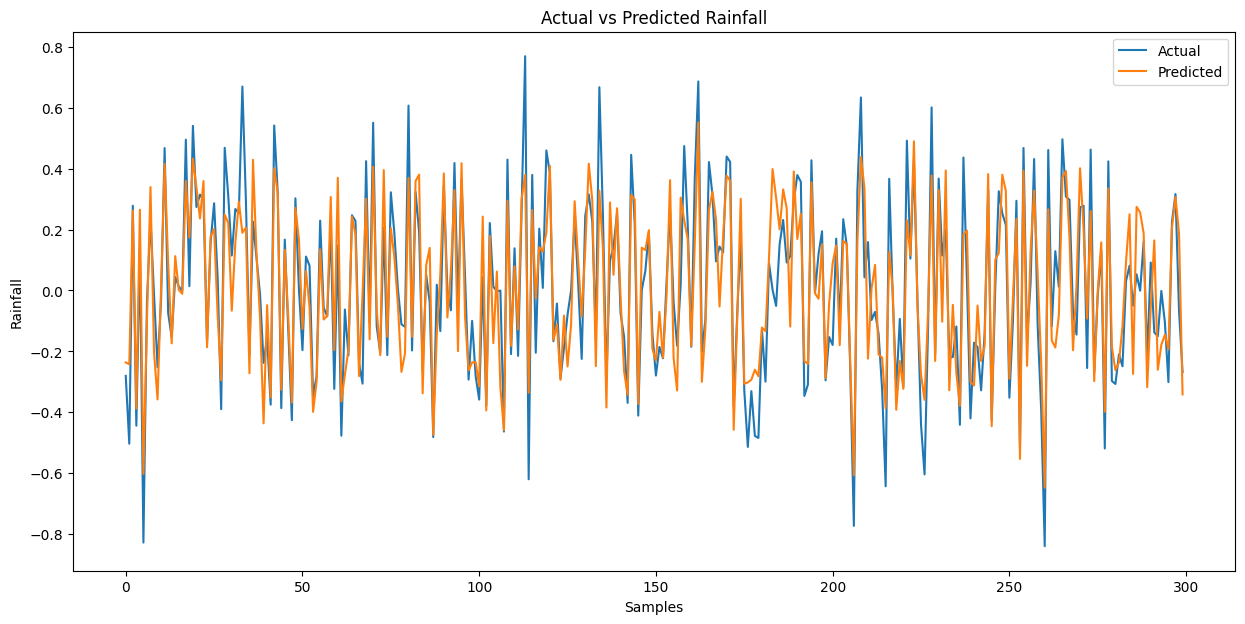

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,7))

plt.plot(y_test_coord.cpu().numpy()[:300],label="Actual")
plt.plot(final_pred[:300],label="Predicted")

plt.xlabel("Samples")
plt.ylabel("Rainfall")
plt.title("Actual vs Predicted Rainfall")

plt.legend()
plt.show()

In [33]:
# Create prediction matrix from coordination_df
pred_matrix = coordination_df[
    [
        "china_pred",
        "nigeria_pred",
        "sa_pred",
        "yemen_pred"
    ]
].values

# Calculate uncertainty (standard deviation across agents)
uncertainty = np.std(pred_matrix, axis=1)

# Add uncertainty as new column
coordination_df["uncertainty"] = uncertainty

print("Uncertainty added successfully")
print(coordination_df[["uncertainty"]].head())

Uncertainty added successfully
   uncertainty
0     0.339331
1     0.213098
2     0.273493
3     0.300829
4     0.382175


In [34]:
results = {
    "Model": [
        "China Agent",
        "Nigeria Agent",
        "South Africa Agent",
        "Yemen Agent",
        "Coordination Agent"
    ],

    "RMSE": [
        0.4005,
        0.1894,
        0.3375,
        0.3126,
        0.1386
    ],

    "MAE": [
        0.3171,
        0.1351,
        0.2537,
        0.2280,
        0.1108
    ],

    "R²": [

        0.6298,
        0.8753,
        0.6958,
        0.8050,
        0.7883
    ]
}

results_df = pd.DataFrame(results)

print(results_df)

                Model    RMSE     MAE      R²
0         China Agent  0.4005  0.3171  0.6298
1       Nigeria Agent  0.1894  0.1351  0.8753
2  South Africa Agent  0.3375  0.2537  0.6958
3         Yemen Agent  0.3126  0.2280  0.8050
4  Coordination Agent  0.1386  0.1108  0.7883


In [36]:
feature_importance = attention_weights.mean(dim=0)

print(feature_importance)

tensor([1.6962e-04, 1.8329e-02, 4.3672e-05, 3.4666e-05, 7.4499e-05, 9.0731e-05,
        3.1759e-05, 8.1317e-05, 9.8599e-05, 2.4968e-04, 1.8979e-05, 2.7466e-05,
        6.6179e-05, 7.6904e-04, 4.3368e-05, 8.6493e-05, 1.1587e-01, 7.9546e-05,
        3.4267e-05, 2.0485e-04, 4.8394e-05, 3.4231e-05, 5.4910e-05, 1.7938e-04,
        1.1872e-04, 5.5976e-05, 2.8521e-04, 4.6049e-05, 4.4070e-05, 6.2117e-05,
        4.2577e-05, 4.7847e-05, 4.3989e-05, 3.0047e-02, 3.0911e-05, 5.0923e-05,
        6.9117e-05, 4.0232e-02, 4.6345e-05, 5.3386e-05, 3.9280e-05, 2.4344e-04,
        4.8364e-05, 1.9513e-04, 5.6702e-05, 8.2634e-05, 1.8791e-03, 3.5283e-05,
        1.8512e-04, 5.0560e-05, 4.4006e-05, 9.4877e-05, 8.2531e-04, 4.1507e-05,
        4.1541e-05, 4.2943e-05, 4.0002e-05, 4.2911e-02, 3.5528e-05, 4.5565e-05,
        5.3729e-05, 3.8375e-05, 1.0515e-03, 3.8273e-05, 2.0130e-03, 6.4796e-02,
        5.7373e-05, 3.7520e-05, 4.1180e-05, 3.4817e-05, 4.1467e-05, 9.3402e-05,
        8.4290e-02, 4.3140e-05, 8.7775e-

In [37]:
feature_importance = torch.abs(
    final_model.feature_proj.weight
).mean(dim=0)

print(feature_importance)

tensor([0.1756, 0.1671, 0.1649, 0.1465, 0.1349, 0.1443, 0.1485, 0.1480, 0.1473,
        0.1626, 0.1379, 0.1455], device='cuda:0', grad_fn=<MeanBackward1>)


In [39]:
feature_names = coordination_df.columns.tolist()

for name, score in zip(
    feature_names,
    feature_importance.detach().cpu().numpy()
):
    print(name, ":", score)

china_pred : 0.1756267
nigeria_pred : 0.16714248
sa_pred : 0.16488236
yemen_pred : 0.14652517
china_r2 : 0.13492812
nigeria_r2 : 0.14426948
sa_r2 : 0.14853357
yemen_r2 : 0.14798477
china_conf : 0.14725631
nigeria_conf : 0.1625952
sa_conf : 0.13794257
yemen_conf : 0.14545533
